# benchmark_01. Version 2.0 Recreates Notebook 01 (and Matches 1.2)

This benchmark validates the **version 2.0** `lrom` package on the
wavefunction studies of `notebooks/01_rbm_vs_lrom_single_wavefunction.ipynb`:
the same two emulation problems are solved with the active 2.0 package and
with the frozen validated snapshot `lrom_legacy.v1_2`, on identical sampling
designs. Because 2.0 only *adds* capability (cross sections, spin-orbit-aware
predictors), every wavefunction-level array — least-squares coefficients,
learned LROM coefficients, reconstructed wavefunctions, and relative-L2
errors — must agree between the two packages to numerical precision.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
for name in list(sys.modules):
    if name in ("lrom", "lrom_legacy") or name.startswith(("lrom.", "lrom_legacy.")):
        del sys.modules[name]

import lrom_legacy.v2_0 as v2_0
import lrom as v1_2

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
print("v2 shell:", v2_0.__version__, "| active v1.2:", v1_2.__version__)

DIFFERENCE_FLOOR = 1e-16

active lrom: 2.0.0 | snapshot: 1.2.0


## The two notebook-01 studies, run through both packages

Study 1: Vv-only (`ws_1`, 35 linspace training / 41 testing, normalized
parameter predictors). Study 2: three-parameter `ws_3` (70/81 Latin
hypercube, six maxvol potential predictors). All sizes, meshes, and seeds
match notebook 01 exactly, so this doubles as a regression record of its
results.

In [2]:
def build(package, potential, training_ranges, testing_ranges, sizes, mesh, strategy, predictor, count):
    emulator = package.LROM(
        target=(40, 20), projectile=(1, 0), lab_energy=14.1,
        l=0, potential=potential,
    )
    emulator.sampling(
        training_ranges=training_ranges, testing_ranges=testing_ranges,
        training_size=sizes[0], testing_size=sizes[1], mesh_size=mesh,
        strategy=strategy, seed=1204, high_fidelity_solver="runge_kutta",
    )
    emulator.train(basis_size=4, predictor=predictor, predictor_count=count)
    return emulator

probe = v2_0.LROM(target=(40, 20), projectile=(1, 0), lab_energy=14.1, l=0, potential="ws_1")
Vv0 = dict(probe.central_parameters)["Vv"]
vv_ranges = ({"Vv": (0.90 * Vv0, 1.10 * Vv0)}, {"Vv": (0.65 * Vv0, 1.35 * Vv0)})

ws3_probe = v2_0.LROM(target=(40, 20), projectile=(1, 0), lab_energy=14.1, l=0, potential="ws_3")
ws3_center = dict(ws3_probe.central_parameters)
ws3_train = {name: (0.90 * ws3_center[name], 1.10 * ws3_center[name]) for name in ("Vv", "Rv", "av")}
ws3_test = {
    "Vv": (0.78 * ws3_center["Vv"], 1.22 * ws3_center["Vv"]),
    "Rv": (0.80 * ws3_center["Rv"], 1.20 * ws3_center["Rv"]),
    "av": (0.80 * ws3_center["av"], 1.20 * ws3_center["av"]),
}

studies = {}
for label, package in (("2.0", v2_0), ("1.2", v1_2)):
    studies[("vv", label)] = build(package, "ws_1", vv_ranges[0], vv_ranges[1],
                                   (35, 41), 800, "linspace", "parameters", 1)
    studies[("ws3", label)] = build(package, "ws_3", ws3_train, ws3_test,
                                    (70, 81), 900, "latin_hypercube", "potential", 6)
print("all four emulators trained")

all four emulators trained


## Array-level agreement

Each quantity below is compared as the maximum absolute difference between
the 2.0 and 1.2 results over the full testing set.

In [3]:
rows = []
for study in ("vv", "ws3"):
    new = studies[(study, "2.0")]
    old = studies[(study, "1.2")]
    pairs = {
        "LS coefficients": (new.testing_results.coefficients["ls"][0],
                            old.testing_results.coefficients["ls"][0]),
        "LROM coefficients": (new.testing_results.coefficients["lrom"][0],
                              old.testing_results.coefficients["lrom"][0]),
        "LROM wavefunctions": (new.testing_results.lrom[0], old.testing_results.lrom[0]),
        "relative L2 (lrom)": (new.testing_results.metrics["relative_l2"][0]["lrom"],
                               old.testing_results.metrics["relative_l2"][0]["lrom"]),
        "relative L2 (ls)": (new.testing_results.metrics["relative_l2"][0]["ls"],
                             old.testing_results.metrics["relative_l2"][0]["ls"]),
    }
    for name, (a, b) in pairs.items():
        rows.append({
            "study": study,
            "quantity": name,
            "max |2.0 - 1.2|": float(np.max(np.abs(np.asarray(a) - np.asarray(b)))),
        })
agreement = pd.DataFrame(rows).set_index(["study", "quantity"])
assert (agreement["max |2.0 - 1.2|"] < 1e-10).all(), agreement
agreement

max |2.0 - 1.2|
study quantity                           
vv    LS coefficients                 0.0
      LROM coefficients               0.0
      LROM wavefunctions              0.0
      relative L2 (lrom)              0.0
      relative L2 (ls)                0.0
ws3   LS coefficients                 0.0
      LROM coefficients               0.0
      LROM wavefunctions              0.0
      relative L2 (lrom)              0.0
      relative L2 (ls)                0.0

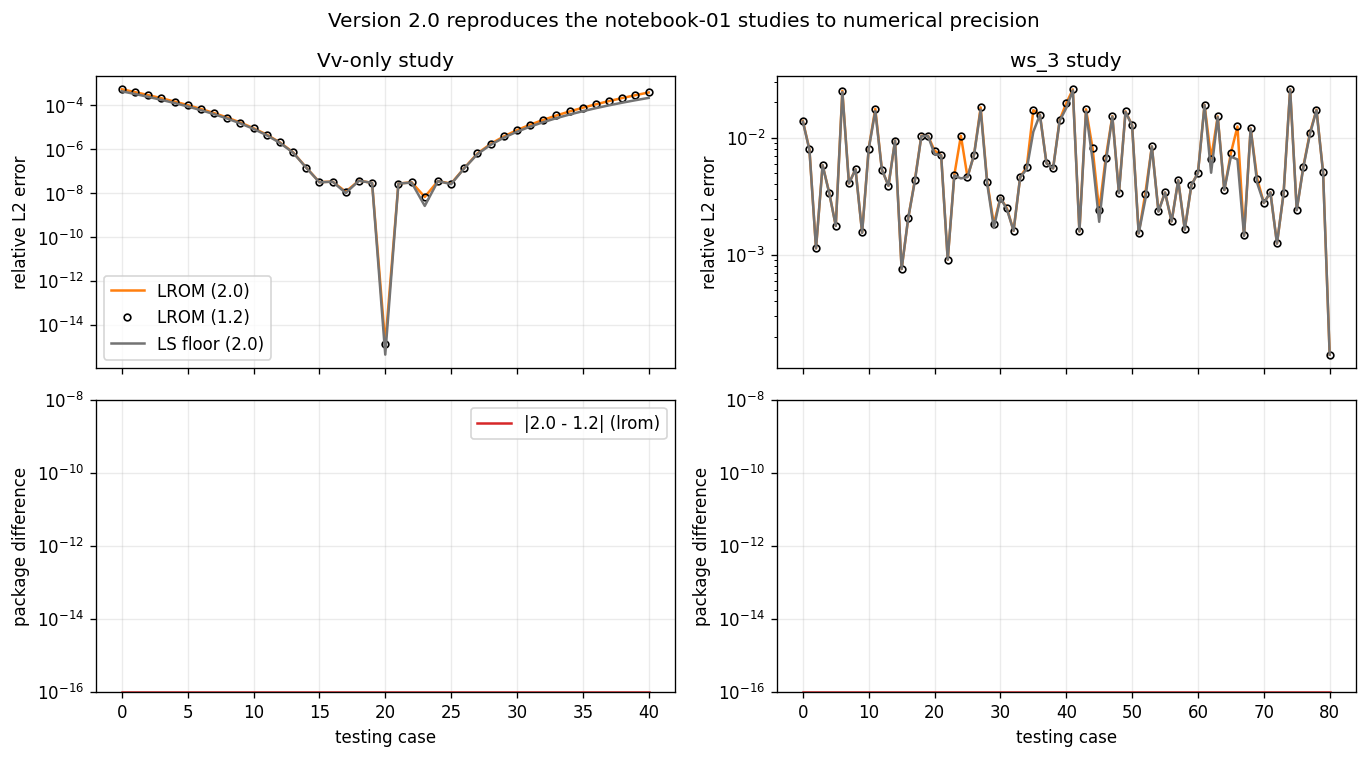

In [4]:
# FIGURE: version-comparison-errors
# Per-case testing errors from both packages: solid = 2.0, open circles = 1.2.
# The lower panel shows the numerical gap between them (machine-level).
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.4), sharex="col")
for column, (study, title) in enumerate((("vv", "Vv-only study"), ("ws3", "ws_3 study"))):
    new = studies[(study, "2.0")].testing_results.metrics["relative_l2"][0]
    old = studies[(study, "1.2")].testing_results.metrics["relative_l2"][0]
    case_number = np.arange(len(new["lrom"]))
    ax = axes[0, column]
    ax.semilogy(case_number, new["lrom"], color="tab:orange", label="LROM (2.0)")
    ax.semilogy(case_number, old["lrom"], "o", markerfacecolor="none",
                markeredgecolor="black", markersize=4, label="LROM (1.2)")
    ax.semilogy(case_number, new["ls"], color="0.45", label="LS floor (2.0)")
    ax.set_title(title)
    ax.set_ylabel("relative L2 error")
    difference_ax = axes[1, column]
    difference_ax.semilogy(
        case_number,
        np.maximum(np.abs(new["lrom"] - old["lrom"]), DIFFERENCE_FLOOR),
        color="tab:red", label="|2.0 - 1.2| (lrom)",
    )
    difference_ax.set_xlabel("testing case")
    difference_ax.set_ylabel("package difference")
    difference_ax.set_ylim(bottom=DIFFERENCE_FLOOR, top=1e-8)
axes[0, 0].legend()
axes[1, 0].legend()
fig.suptitle("Version 2.0 reproduces the notebook-01 studies to numerical precision")
fig.tight_layout()
plt.show()

## What to notice

The 2.0 package reproduces every wavefunction-level quantity of the frozen
1.2 snapshot to numerical precision on both notebook-01 studies. The new
cross-section capability therefore extends the emulator without perturbing
the validated wavefunction physics.